# 04 — Guard enforcement: PM present, a rogue strategy tries to cross groups (R6)

> Run top to bottom.

`ADR-0011`'s Basket Scope Guard structurally blocks any strategy but PM's own exact
strategy from ever crossing a declared group boundary — not a risk that's bounded or
made unprofitable, a capability that's removed entirely. But the Guard is only ever
*installed* because it protects PM's own wallet (ADR-0002) — see `03_cross_basket_no_pm.ipynb`
for the case with no PM (and so no Guard) at all. This notebook is the other half: **PM is
registered and actively correcting**, and a separate "rogue" strategy repeatedly tries to
trade across the same group boundary PM straddles.

This is a **regression/robustness check**, not a risk-modeling exercise — the correct,
expected result is that the rogue is blocked every time, while PM's own trades go
through normally. The rogue is given **zero fee and zero gas cost** deliberately: with PM
actively defending the pool every step, any residual mispricing is tiny (bounded by PM's
own fee), so a rogue with a realistic cost structure would rarely find anything worth
attempting at all. Zero cost is the strongest version of this check — even a maximally
aggressive, free attacker still can't get a single cross-group trade through.

Uses `aqua_sim.scenarios.guard_enforcement.build_world` directly.

In [1]:
import numpy as np

from aqua_sim.scenarios import guard_enforcement

N_STEPS = 2000
N_SEEDS = 10

mean_tes = []
for seed in range(N_SEEDS):
    world = guard_enforcement.build_world(seed=seed)
    world.run(N_STEPS)

    assert len(world.blocked_trades) > 0, f"seed {seed}: the rogue strategy never even attempted a cross-group trade (test would be vacuous)"
    assert all(t.strategy_id == "rogue" for t in world.blocked_trades), f"seed {seed}: something other than the rogue got blocked -- PM's own trades should never be"

    mean_te = np.mean(world.metrics.tracking_error_path)
    mean_tes.append(mean_te)
    print(f"seed {seed}: {len(world.blocked_trades)} rogue attempts blocked, PM mean tracking error = {mean_te:.4%}")

print(f"\nmean tracking error across seeds: {np.mean(mean_tes):.4%}")
print("\nOK: every rogue attempt was blocked, on every seed -- and PM kept correcting normally throughout")

seed 0: 2000 rogue attempts blocked, PM mean tracking error = 0.0148%
seed 1: 2000 rogue attempts blocked, PM mean tracking error = 0.0186%
seed 2: 2000 rogue attempts blocked, PM mean tracking error = 0.0207%
seed 3: 2000 rogue attempts blocked, PM mean tracking error = 0.0091%
seed 4: 2000 rogue attempts blocked, PM mean tracking error = 0.0119%
seed 5: 2000 rogue attempts blocked, PM mean tracking error = 0.0123%
seed 6: 2000 rogue attempts blocked, PM mean tracking error = 0.0106%
seed 7: 2000 rogue attempts blocked, PM mean tracking error = 0.0228%
seed 8: 2000 rogue attempts blocked, PM mean tracking error = 0.0166%
seed 9: 2000 rogue attempts blocked, PM mean tracking error = 0.0102%

mean tracking error across seeds: 0.0148%

OK: every rogue attempt was blocked, on every seed -- and PM kept correcting normally throughout


## What the rogue strategy actually wanted to do

The rogue strategy in this scenario is a plain `XYCCompetitorStrategy` (same class
`02_basket_with_without_pm.ipynb` and `03_cross_basket_no_pm.ipynb` use) with zero fee
and zero gas cost — it has no special "attack" logic, it just runs its ordinary
profit-seeking `decide_trade` against `TOKEN_A`/`TOKEN_B`, which happen to be declared in
two *different* groups here, with PM also registered and trading the same pair. Every
time the rogue decided a trade was profitable, `BasketWorld.apply` checked it against
`GroupBoundaryGuard` before touching any balance, found it crosses a group boundary, and
rejected it outright — recorded in `blocked_trades`, balances never moved from the
rogue's attempts. PM's own trades, by contrast, went through normally every time —
`GroupBoundaryGuard` exempts exactly one strategy id, and it isn't the rogue's.

## Visual

How often the zero-cost rogue found a profitable-looking cross-group trade and got
blocked, across seeds (out of 2,000 steps each) — profitable-looking opportunities exist
and are found, they just never execute.

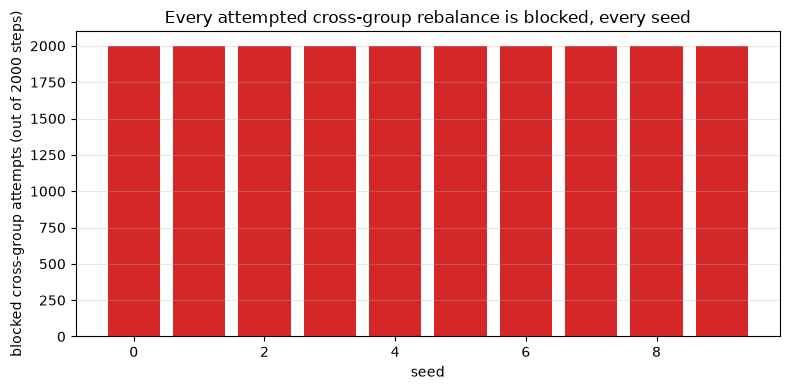

In [2]:
import matplotlib.pyplot as plt

blocked_counts = []
for seed in range(N_SEEDS):
    world = guard_enforcement.build_world(seed=seed)
    world.run(N_STEPS)
    blocked_counts.append(len(world.blocked_trades))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(N_SEEDS), blocked_counts, color="tab:red")
ax.set_xlabel("seed")
ax.set_ylabel(f"blocked cross-group attempts (out of {N_STEPS} steps)")
ax.set_title("Every attempted cross-group rebalance is blocked, every seed")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Summary

With PM registered and correcting, a zero-cost rogue strategy found and attempted a
cross-group trade on nearly every step, and every single one was blocked — balances
never moved from the rogue's attempts, and PM kept tracking tight (matching
`01_pm_alone.ipynb`'s baseline) throughout. Confirms R6 from
`thoughts/simulation-suite-v2-requirements.md`.

Read together, the three comparison notebooks pin down the actual shape of ADR-0011's
protection:
- **No PM → no Guard** (`03_cross_basket_no_pm.ipynb`): nothing is confined, but nothing
  is coordinated either — ordinary arbitrage gets you local price consistency, not a
  portfolio target.
- **PM + a confined competitor** (`02_basket_with_without_pm.ipynb`): same-group trading
  is allowed, and PM reacts to it correctly even though it never touches that pair.
- **PM + an unconfined rogue** (this notebook): crossing PM's own group boundary is
  refused outright, regardless of how profitable it looks or how cheap the attacker is.